In [1]:
import numpy as np
import json
from transformers import BertTokenizer, BertModel, BertForMaskedLM
from tqdm import tqdm
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import spacy
import copy
import itertools
import seaborn as sns
import os

/opt/anaconda3/envs/m1-gender/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
#BERTモデル
model_version = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_version)
model = BertModel.from_pretrained(model_version, output_attentions=True)
model.eval()
print()

In [22]:
#作ったデータセットの読み込み
with open("occupation_male.json") as f:
    data_male = json.load(f)
    
with open("occupation_female.json") as f:
    data_female = json.load(f)

#### 文章中で性別単語にあたっているAttention値の平均

In [23]:
def context_using_head(occupation_word):
    context_values = []
    texts_male = data_male[occupation_word]
    texts_female = data_female[occupation_word]
    lists = [[[] for _ in range(12)] for _ in range(12)]
    counter_r = 0
    
    for s in tqdm(range(len(texts_male))): #100文でループ
        counter = 0
        sent_male = texts_male[s]
        sent_female = texts_female[s]
        pos_gender = []
            
        #文のトークナイズ男性
        inputs_male = tokenizer(sent_male, return_tensors='pt')
        tokens_male = tokenizer.convert_ids_to_tokens(inputs_male.input_ids[0])  
        #文のトークナイズ女性
        inputs_female = tokenizer(sent_female, return_tensors='pt')
        tokens_female = tokenizer.convert_ids_to_tokens(inputs_female.input_ids[0])
        #性別単語の位置
        for i in range(len(tokens_male)):
            if tokens_male[i] in tokens_female:
                pos_gender.append(i)
            
        for i in pos_gender:
            if tokens_male[i] != tokens_female[i]:
                counter+=1
                counter_r+=1
                print(s, tokens_male[i], tokens_female[i])
                break
            
        if counter != 0:
            continue
            
        #男性語文のAttention
        with torch.no_grad():
            outputs_m = model(**inputs_male, output_attentions=True)
            attentions_m = outputs_m["attentions"]
        #女性語文のAttention
        with torch.no_grad():
            outputs_f = model(**inputs_female, output_attentions=True)
            attentions_f = outputs_f["attentions"]
            
        for layer in range(12):
            attentions_numpy_m = attentions_m[layer][0].detach().numpy() #現在の層とバッチの取り出し
            attentions_numpy_f = attentions_f[layer][0].detach().numpy() #現在の層とバッチの取り出し
                
            for head in range(12):
                value = 0
                current_attention_m = attentions_numpy_m[head] #男性語
                current_attention_f = attentions_numpy_f[head] #女性語
                
                to_he = 0
                to_she = 0
                
                for pos in pos_gender:
                    to_he += current_attention_m[pos, 1]
                    to_she += current_attention_f[pos, 1]
                
                avg_he = to_he/len(pos_gender)
                avg_she = to_she/len(pos_gender)
                diff = avg_he - avg_she
                    
                lists[layer][head].append(diff)
                
    return lists, counter_r

In [ ]:
result = {}
target_occupations = ['carpenter', 'driver', 'sheriff', 'developer', 'farmer', 'guard', 'chief', 
                       'lawyer', 'cook', 'physician', 'CEO', 'analyst', 'manager', 'supervisor', 
                       'editor', 'designer', 'accountant', 'auditor', 'writer', 'baker', 'clerk',
                       'counselor', 'attendant', 'teacher', 'sewer', 'librarian', 'assistant', 
                       'cleaner', 'housekeeper', 'nurse', 'receptionist', 'secretary']

for ow in target_occupations:
    result_list = []
    result_list, counter = context_using_head(ow)
    
    print(ow, len(result_list[0][0]), counter)
    result[ow] = result_list  

In [34]:
with open('result_context_using_head.json', 'w') as f:
    json.dump(result, f)

### 性別単語を[MASK]で置き換えて予測

In [36]:
#BERTモデル
model_version = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_version)
model = BertForMaskedLM.from_pretrained(model_version, output_attentions=True)
model.eval()
print()

/opt/anaconda3/envs/m1-gender/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (

In [37]:
def mask_prediction(occupation):
    # 性別単語を[MASK]，　主語を予測
    occupation_word = occupation
    male_sentences = data_male[occupation_word]
    female_sentences = data_female[occupation_word]
    mask_id = tokenizer.mask_token_id
    she_token_id = tokenizer.convert_tokens_to_ids("she")
    he_token_id = tokenizer.convert_tokens_to_ids("he")
    probs = []
    counter = 0

    for i in tqdm(range(len(male_sentences))):
        pos_m = []
        pos_f = []
        sent_male = male_sentences[i]
        sent_female = female_sentences[i]
    
        #文のトークナイズ男性
        inputs_male = tokenizer(sent_male, return_tensors='pt')
        tokens_male = tokenizer.convert_ids_to_tokens(inputs_male.input_ids[0])
    
        #文のトークナイズ女性
        inputs_female = tokenizer(sent_female, return_tensors='pt')
        tokens_female = tokenizer.convert_ids_to_tokens(inputs_female.input_ids[0])
    
        #性別単語の位置
        for j in range(len(tokens_male)):
            if tokens_male[j] not in tokens_female:
                pos_m.append(j)
    
        for j in range(len(tokens_female)):
            if tokens_female[j] not in tokens_male:
                pos_f.append(j)

        #性別の単語をマスク
        for pos in pos_m:
            inputs_male["input_ids"][0, pos] = mask_id
    
        for pos in pos_f:
            inputs_female["input_ids"][0, pos] = mask_id
    
        if tokenizer.convert_ids_to_tokens(inputs_male['input_ids'][0])!= tokenizer.convert_ids_to_tokens(inputs_female['input_ids'][0]):
            print(tokenizer.convert_ids_to_tokens(inputs_male['input_ids'][0]))
            print(tokenizer.convert_ids_to_tokens(inputs_female['input_ids'][0]), "\n")
    
        with torch.no_grad():
            outputs = model(**inputs_male)
            logits = outputs.logits
        
        mask_logits = logits[0, pos_m[0], :]
        probabilities = F.softmax(mask_logits, dim=-1)
        predicted_token_id = mask_logits.argmax(dim=-1)
        predicted_token = tokenizer.decode([predicted_token_id])
    
        #print('sheが予測される確率 : ', probabilities[she_token_id].item())
        #print('heが予測される確率 : ', probabilities[he_token_id].item(), "\n")
        
        he_she = (probabilities[he_token_id].item() - probabilities[she_token_id].item())
        probs.append(he_she)
    
    return probs

In [ ]:
mask_result = {}
target_occupations = ['carpenter', 'driver', 'sheriff', 'developer', 'farmer', 'guard', 'chief', 
                       'lawyer', 'cook', 'physician', 'CEO', 'analyst', 'manager', 'supervisor', 
                       'editor', 'designer', 'accountant', 'auditor', 'writer', 'baker', 'clerk',
                       'counselor', 'attendant', 'teacher', 'sewer', 'librarian', 'assistant', 
                       'cleaner', 'housekeeper', 'nurse', 'receptionist', 'secretary']

for ow in target_occupations:
    result = mask_prediction(ow)
    
    print(ow, len(result))
    mask_result[ow] = result  

In [40]:
with open("mask_prediction.json", "w") as f:
    json.dump(mask_result, f)

### 相関係数を記録

In [6]:
with open("result_context_using_head.json", "r") as f:
    attentions = json.load(f)

with open("mask_prediction.json", "r") as f:
    prediction_probs = json.load(f)

target_occupations = ['carpenter', 'driver', 'sheriff', 'developer', 'farmer', 'guard', 'chief', 
                       'lawyer', 'cook', 'physician', 'CEO', 'analyst', 'manager', 'supervisor', 
                       'editor', 'designer', 'accountant', 'auditor', 'writer', 'baker', 'clerk',
                       'counselor', 'attendant', 'teacher', 'sewer', 'librarian', 'assistant', 
                       'cleaner', 'housekeeper', 'nurse', 'receptionist', 'secretary']
probs = []
for t in target_occupations:
    probs += prediction_probs[t]
print(len(probs))
    
correlations = [[] for _ in range(12)]
for l in range(12):
    for h in range(12):
        tmp = []
        for o in target_occupations:
            tmp += attentions[o][l][h]
        #相関係数を求める
        correlation = np.corrcoef(tmp, probs)[0, 1]
        correlations[l].append(round(correlation, 3))
        
            

3200


### 相関係数の可視化

In [10]:
import pandas as pd

# 行インデックス（行名）と列名を作る
row_labels = [f"layer{i}" for i in range(12)]
col_labels = [f"head{j}" for j in range(12)]

df = pd.DataFrame(correlations, index=row_labels, columns=col_labels)
print(df)
df.to_csv("correlations.csv", index=True, header=True)

         head0  head1  head2  head3  head4  head5  head6  head7  head8  head9  \
layer0   0.032 -0.015 -0.030  0.210 -0.360 -0.166 -0.045  0.159  0.050 -0.056   
layer1  -0.196  0.159 -0.100 -0.362  0.307 -0.017  0.039 -0.359 -0.380 -0.456   
layer2  -0.021 -0.170  0.048 -0.558  0.082  0.124  0.020 -0.176  0.649 -0.008   
layer3  -0.014 -0.249  0.343 -0.360 -0.346 -0.070  0.047  0.058 -0.073 -0.224   
layer4  -0.499  0.351 -0.384 -0.102  0.445  0.110 -0.467  0.128 -0.513 -0.517   
layer5   0.009  0.195 -0.343  0.571 -0.157  0.328  0.402  0.224 -0.187 -0.332   
layer6   0.117 -0.083 -0.227  0.141 -0.456 -0.001 -0.322 -0.347  0.244  0.090   
layer7  -0.155  0.058  0.003  0.341  0.107 -0.503 -0.032 -0.147  0.257  0.080   
layer8  -0.108 -0.113 -0.100  0.319  0.124  0.024  0.276 -0.261 -0.489 -0.266   
layer9  -0.369 -0.450 -0.428 -0.641 -0.261 -0.504 -0.578 -0.321  0.083 -0.412   
layer10  0.182 -0.318 -0.279 -0.624 -0.477 -0.315 -0.724 -0.509 -0.085 -0.445   
layer11 -0.147 -0.239 -0.039

<Axes: >

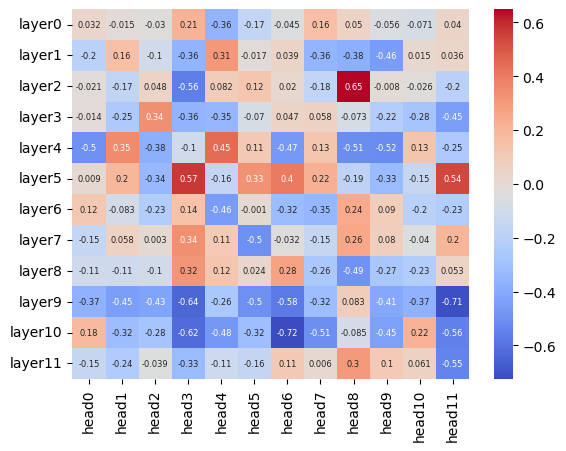

In [50]:
df = pd.read_csv("correlations.csv", index_col=0)
sns.heatmap(df, annot=True, cmap="coolwarm", annot_kws={'size': 6})

#### 相関係数の値が大きい層とヘッドを使って可視化

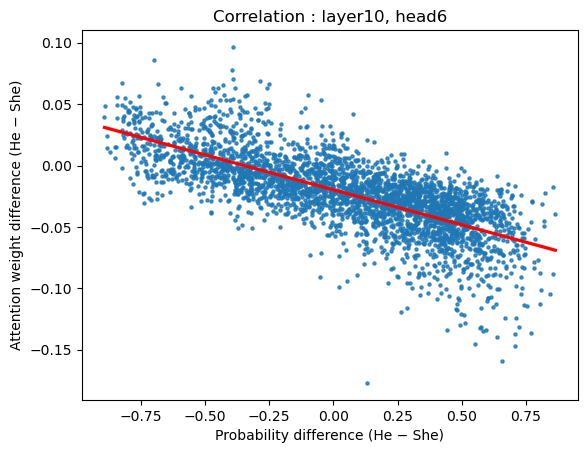

In [60]:
l = 10
h = 6

y = []
for t in target_occupations:
    y += attentions[t][l][h]
x = probs

# 回帰直線の係数を計算（傾きa、切片b）
#x = np.array(x)
#y = np.array(y)
#a, b = np.polyfit(x, y, 1)

# 回帰直線のy値を計算
#y_pred = a * x + b

#plt.scatter(x, y, s =10)
#plt.plot(x, y_pred, color='red', label='Regression line')  # 回帰直線
sns.regplot(x=x, y=y, line_kws={'color': 'red'}, scatter_kws={"s": 5})
plt.title(f"Correlation : layer{l}, head{h}")
plt.xlabel("Probability difference (He − She)")
plt.ylabel("Attention weight difference (He − She)")
plt.show()

### 同じ職業間で違いが見られるか

In [ ]:
for t in target_occupations:
    x = prediction_probs[t]
    y = attentions[t][10][6]
    
    # 散布図を描画
    plt.figure()
    plt.scatter(x, y)
    sns.regplot(x=x, y=y, line_kws={"color": "red"}) 
    plt.title(f"occupation : {t}")
    plt.xlabel('Difference of MASK prediction')
    plt.ylabel('Dfference of Attention weight')
    #plt.show()
    plt.savefig(f'result/{t}.png', )

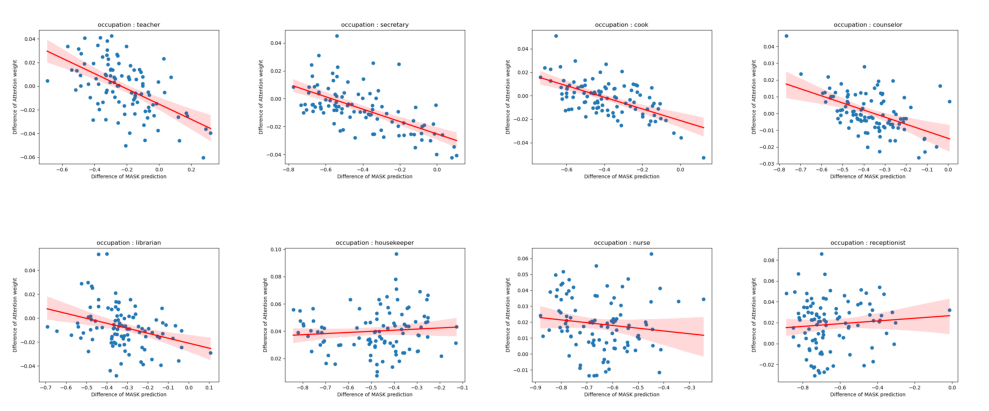

In [42]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

filepaths = ['result/teacher.png', 'result/secretary.png', 'result/cook.png', 'result/counselor.png',
             'result/librarian.png', 'result/housekeeper.png', 'result/nurse.png', 'result/receptionist.png']

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = mpimg.imread(filepaths[i])
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()